# [**Go to Web App**](https://huggingface.co/spaces/chrysostomosS/LandCoverApp)

## EuroSAT Dataset (RGB)

The model is trained on the EuroSAT RGB version, consisting of 27,000+ satellite images (64×64 pixels).
The dataset is structured into 10 labeled classes representing various land cover types from Sentinel-2 satellite imagery.

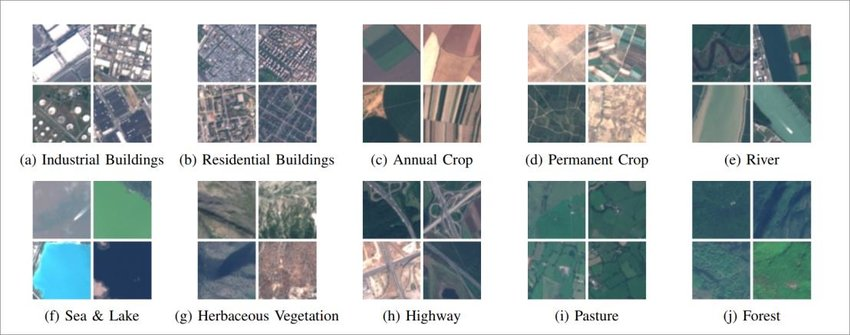

## Load Dataset

In [1]:
!wget https://madm.dfki.de/files/sentinel/EuroSAT.zip --no-check-certificate
!unzip EuroSAT.zip

Streaming output truncated to the last 5000 lines.
  inflating: 2750/SeaLake/SeaLake_2206.jpg  
  inflating: 2750/SeaLake/SeaLake_1313.jpg  
  inflating: 2750/SeaLake/SeaLake_263.jpg  
  inflating: 2750/SeaLake/SeaLake_967.jpg  
  inflating: 2750/SeaLake/SeaLake_515.jpg  
  inflating: 2750/SeaLake/SeaLake_1465.jpg  
  inflating: 2750/SeaLake/SeaLake_1817.jpg  
  inflating: 2750/SeaLake/SeaLake_2902.jpg  
  inflating: 2750/SeaLake/SeaLake_2570.jpg  
  inflating: 2750/SeaLake/SeaLake_1004.jpg  
  inflating: 2750/SeaLake/SeaLake_174.jpg  
  inflating: 2750/SeaLake/SeaLake_2111.jpg  
  inflating: 2750/SeaLake/SeaLake_2388.jpg  
  inflating: 2750/SeaLake/SeaLake_1948.jpg  
  inflating: 2750/SeaLake/SeaLake_838.jpg  
  inflating: 2750/SeaLake/SeaLake_2738.jpg  
  inflating: 2750/SeaLake/SeaLake_1999.jpg  
  inflating: 2750/SeaLake/SeaLake_2359.jpg  
  inflating: 2750/SeaLake/SeaLake_2660.jpg  
  inflating: 2750/SeaLake/SeaLake_1775.jpg  
  inflating: 2750/SeaLake/SeaLake_605.jpg  
  inflatin

Load EuroSAT using ImageDataGenerator:

In [2]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

In [5]:
data_dir = os.path.join('2750')
print(f'Data at: {data_dir}')

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,    # Randomly rotates the image up to ±20 degrees. Helps the model generalize to images that are slightly rotated.
    horizontal_flip=True, # Randomly flips images left-to-right during training. Useful for datasets where left/right orientation isn't fixed.
    zoom_range=0.2        # Randomly zooms in or zooms out on the image up to 20%. Helps the model handle slight changes in object size.
)

train_dataset = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224), # MobileNetV3 receives images 224 x 224
    batch_size=32, # Each class of the iterator loads 32 pairs of image-label
    shuffle=True,
    subset='training'
)

val_dataset = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    shuffle=False,
    subset='validation'
)

print(f'{train_dataset.samples + val_dataset.samples} images loaded.')

Data at: 2750
Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
27000 images loaded.


## Load MobileNetV3Small

In [6]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model

# Load the pre-trained MobileNetV3Small model
base_model = MobileNetV3Small(
    weights='imagenet',       # Load pre-trained weights from ImageNet
    include_top=False,        # Exclude the final classification layer
    input_shape=(224, 224, 3),# Set the input shape to match MobileNetV3's requirements
    pooling='avg'             # Apply average pooling to condense the features into a smaller vector
)

model = Model(inputs=base_model.input, outputs=base_model.output)
print(f"The base model has {len(base_model.layers)} layers.")

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
The base model has 158 layers.


## Model Training

**Architecture**
* **Base Model**: MobileNetV3Small (pretrained on ImageNet, top removed, average pooled)
* **New Layers**:
  1. Fully connected (Dense) layer with 256 units and ReLU activation
  2. Dropout layer (rate = 0.3) for regularization
  3. Final Dense layer with 10 units and softmax activation for classification
* **Optimizer**: Adam with custom learning rate (initially 1e-3, then 1e-5 during fine-tuning)
* **Loss**: Categorical Crossentropy
* **Metrics**: Accuracy
* **Callbacks Used**:
EarlyStopping
ReduceLROnPlateau

**Initial Training**

We will train the model in two phases. First, we train only the newly added classification layers for 5 epochs while keeping the weights of the pre-trained MobileNetV3Small base model frozen. This helps the new layers learn to interpret the features extracted by the base model without disrupting the valuable pre-trained weights.

In [ ]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Freeze base model initially
base_model.trainable = False

# Add new classifier
x = base_model.output
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train classifier layers first
initial_history = model.fit(train_dataset, validation_data=val_dataset, epochs=5, callbacks=[reduce_lr, early_stop])


Epoch 1/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 615s 901ms/step - accuracy: 0.8020 - loss: 0.5826 - val_accuracy: 0.9307 - val_loss: 0.2019 - learning_rate: 0.0010
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 591s 875ms/step - accuracy: 0.9213 - loss: 0.2290 - val_accuracy: 0.9420 - val_loss: 0.1725 - learning_rate: 0.0010
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 653s 921ms/step - accuracy: 0.9309 - loss: 0.1987 - val_accuracy: 0.9389 - val_loss: 0.1616 - learning_rate: 0.0010
Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 617s 914ms/step - accuracy: 0.9367 - loss: 0.1814 - val_accuracy: 0.9474 - val_loss: 0.1508 - learning_rate: 0.0010
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 613s 908ms/step - accuracy: 0.9406 - loss: 0.1743 - val_accuracy: 0.9509 - val_loss: 0.1481 - learning_rate: 0.0010
Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 760s 1s/step - accuracy: 0.8394 - loss: 0.5570 - val_accuracy: 0.9426 - val_loss: 0.1729 - learning_rate: 1.0000e-05
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 717s 1s/step - accuracy: 0.9

**Fine-Tuning**

After training the new classifier on top of the frozen base model, we can further improve the model's performance by "fine-tuning". This involves unfreezing some of the later (50) layers in the pre-trained base model and training them alongside the new classifier with a very low learning rate (1e-5) for 10 more epochs. This allows the model to make small adjustments to the pre-trained weights, adapting them more specifically to the EuroSAT dataset.

In [ ]:
# === Fine-Tuning ===

# Unfreeze the last 50 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune the model
fine_tune_history = model.fit(train_dataset, validation_data=val_dataset, epochs=10, callbacks=[reduce_lr, early_stop])

Final model is exported in ".keras" format and used in a Gradio app.

In [ ]:
# Save the final model
model.save("eurosat_classifier.keras")


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_7[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_126      │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation_126[0… │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_98 (ReLU)     │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu_98[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_63 (Add)        │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_99 (ReLU)     │ (None, 1, 1, 16)  │          0 │ add_63[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_63         │ (None, 1, 1, 16)  │          0 │ re_lu_99[0][0]    │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu_98[0][0],   │
│ (Multiply)          │ 16)               │            │ multiply_63[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,089,402 (4.16 MB)

 Trainable params: 886,770 (3.38 MB)

 Non-trainable params: 202,632 (791.53 KB)

## App using Gradio

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image
import requests
from io import BytesIO

model = load_model("eurosat_classifier.keras", compile=False)

class_names = ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial',
               'Pasture', 'Permanent Crop', 'Residential', 'River', 'Sea/Lake']

def predict(image):
    image = image.resize((224, 224))
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    preds = model.predict(image)[0]
    top_indices = preds.argsort()[-3:][::-1]
    result = {class_names[i]: float(preds[i]) for i in top_indices}
    return result

def load_image_from_url(url, display_size=(1000, 400)):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    image = image.resize(display_size)
    return image

with gr.Blocks() as demo:
    gr.Markdown("## 🌍 Land Use and Land Cover Classification")
    gr.Markdown("""Upload a satellite or aerial image, or select one of the example images below to classify it into 1 of the 10 land use categories.
Categories include: Annual Crop, Forest, Herbaceous Vegetation, Highway, Industrial, Pasture, Permanent Crop, Residential, River, Sea/Lake
""")

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Input Image")
            with gr.Row():
                submit_btn = gr.Button("Submit", variant="primary")
                clear_btn = gr.ClearButton(components=[image_input])
        output = gr.Label(num_top_classes=3)

    submit_btn.click(fn=predict, inputs=image_input, outputs=output)

    gr.Markdown("### 🖼️ Example Images (click to load)")

    with gr.Row():
        btn1 = gr.Button(value="Athens, Greece 🏙️")
        btn2 = gr.Button(value="Autobahn, Germany 🚗")
        btn3 = gr.Button(value="Amazon River 🌊")

    btn1.click(fn=lambda: load_image_from_url(
        "https://storage.googleapis.com/p-oaf-ibe-back-00e-strapi-uploads/Pl_A_iades_Neo_Athens_Greece_4bd3eabcee/Pl_A_iades_Neo_Athens_Greece_4bd3eabcee.jpg"),
        outputs=image_input)

    btn2.click(fn=lambda: load_image_from_url(
        "https://www.shutterstock.com/image-photo/aerial-drone-view-road-junction-600nw-2380656867.jpg"),
        outputs=image_input)

    btn3.click(fn=lambda: load_image_from_url(
        "https://upload.wikimedia.org/wikipedia/commons/thumb/5/56/Amazon17_%285641020319%29.jpg/330px-Amazon17_%285641020319%29.jpg"),
        outputs=image_input)

demo.launch()



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://65b59685bc909f31d8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Upload on Hugging Face Spaces

Install and log in to Hugging Face


In [ ]:
!pip install -q huggingface_hub
from huggingface_hub import login

In [ ]:
login()

Prepare files


In [ ]:
import os

# Create a new directory for the Space
repo_name = "eurosat-classifier"
os.makedirs(repo_name, exist_ok=True)

# 1. Save the app.py script
app_code = '''import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image
import requests
from io import BytesIO

model = load_model("eurosat_classifier.keras", compile=False)

class_names = ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial',
               'Pasture', 'Permanent Crop', 'Residential', 'River', 'Sea/Lake']

def predict(image):
    image = image.resize((224, 224))
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    preds = model.predict(image)[0]
    top_indices = preds.argsort()[-3:][::-1]
    result = {class_names[i]: float(preds[i]) for i in top_indices}
    return result

def load_image_from_url(url, display_size=(1000, 400)):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    image = image.resize(display_size)
    return image

with gr.Blocks() as demo:
    gr.Markdown("## 🌍 Land Use and Land Cover Classification")
    gr.Markdown("""Upload a satellite or aerial image, or select one of the example images below to classify it into 1 of the 10 land use categories.
Categories include: Annual Crop, Forest, Herbaceous Vegetation, Highway, Industrial, Pasture, Permanent Crop, Residential, River, Sea/Lake
""")

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Input Image")
            with gr.Row():
                submit_btn = gr.Button("Submit", variant="primary")
                clear_btn = gr.ClearButton(components=[image_input])
        output = gr.Label(num_top_classes=3)

    submit_btn.click(fn=predict, inputs=image_input, outputs=output)

    gr.Markdown("### 🖼️ Example Images (click to load)")

    with gr.Row():
        btn1 = gr.Button(value="Athens, Greece 🏙️")
        btn2 = gr.Button(value="Autobahn, Germany 🚗")
        btn3 = gr.Button(value="Amazon River 🌊")

    btn1.click(fn=lambda: load_image_from_url(
        "https://storage.googleapis.com/p-oaf-ibe-back-00e-strapi-uploads/Pl_A_iades_Neo_Athens_Greece_4bd3eabcee/Pl_A_iades_Neo_Athens_Greece_4bd3eabcee.jpg"),
        outputs=image_input)

    btn2.click(fn=lambda: load_image_from_url(
        "https://www.shutterstock.com/image-photo/aerial-drone-view-road-junction-600nw-2380656867.jpg"),
        outputs=image_input)

    btn3.click(fn=lambda: load_image_from_url(
        "https://upload.wikimedia.org/wikipedia/commons/thumb/5/56/Amazon17_%285641020319%29.jpg/330px-Amazon17_%285641020319%29.jpg"),
        outputs=image_input)

demo.launch()
'''
with open(f"{repo_name}/app.py", "w") as f:
    f.write(app_code)

# 2. Create requirements.txt
with open(f"{repo_name}/requirements.txt", "w") as f:
    f.write("gradio\ntensorflow\npillow\nnumpy\n")

# 3. Copy the model file
!cp eurosat_classifier.keras {repo_name}/


Push to Hugging Face Spaces


In [ ]:
from huggingface_hub import create_repo, upload_folder

# Upload everything in the folder to the space
upload_folder(
    folder_path="eurosat-classifier",
    path_in_repo=".",  # root of the Space
    repo_id="chrysostomosS/LandCoverApp",
    repo_type="space"
)


# [**Go to Web App**](https://huggingface.co/spaces/chrysostomosS/LandCoverApp)